# Notebook 06 — rioxarray

**What you will learn:**
- How rioxarray's `.rio` accessor extends xarray with spatial operations
- How to attach a CRS to a Dataset and what it physically stores
- How reprojection changes pixel geometry (but not values)
- How to clip a Dataset to a polygon
- How to export a GeoTIFF and a Cloud-Optimized GeoTIFF (COG)

---

## Background: rioxarray

rioxarray is an **accessor** — a Python namespace (`ds.rio.*`) attached to xarray objects at import time. It does not change xarray's data model; it adds spatial methods:

| Method | What it does |
|--------|--------------|
| `set_spatial_dims()` | Tells rioxarray which dims are x and y |
| `write_crs()` | Stores a CRS string in the array's `.attrs` |
| `crs` | Returns a `pyproj.CRS` object |
| `transform()` | Returns the Affine transform |
| `bounds()` | Returns `(left, bottom, right, top)` in the native CRS |
| `reproject()` | Warps all pixels to a new CRS |
| `clip()` | Masks pixels outside a geometry |
| `to_raster()` | Writes a GeoTIFF or COG |

In [1]:
import sys
sys.path.insert(0, "..")

import xarray as xr
import rioxarray          # registers .rio accessor
import numpy as np
import matplotlib.pyplot as plt
from utils.geo_helpers import clip_to_aoi, reproject_to_wgs84, write_cog, AOI_UTM

ZARR_ENRICHED = "../data/sentinel2_enriched.zarr"
ds = xr.open_zarr(ZARR_ENRICHED)
print(ds)

<xarray.Dataset> Size: 289MB
Dimensions:      (time: 4, y: 2788, x: 2158)
Coordinates:
  * time         (time) datetime64[ns] 32B 2023-06-04T16:02:09.577000 ... 202...
  * x            (x) float64 17kB 4.355e+05 4.355e+05 ... 4.786e+05 4.786e+05
  * y            (y) float64 22kB 4.428e+06 4.428e+06 ... 4.372e+06 4.372e+06
Data variables:
    blue         (time, y, x) uint16 48MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 48MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    ndvi         (time, y, x) float32 96MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) uint16 48MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 48MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    spatial_ref  int64 8B ...


## Step 1: Set spatial dims and attach CRS

After opening from Zarr, `.rio.crs` may be `None` — the CRS was stored as an attribute string, not a live `pyproj.CRS`. We re-attach it explicitly.

The **Affine transform** maps pixel indices `(row, col)` to spatial coordinates `(x, y)` in the CRS. It encodes pixel size, origin, and rotation.

In [2]:
print("CRS before write_crs:", ds.rio.crs)

ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y")
ds = ds.rio.write_crs("EPSG:32618")

print("CRS after  write_crs:", ds.rio.crs)
print("EPSG code:            ", ds.rio.crs.to_epsg())
print()
print("Affine transform:")
print(ds.rio.transform())
print()
print("Bounds (left, bottom, right, top) in UTM metres:")
print(ds.rio.bounds())
print()
print("Spatial resolution (metres):", ds.rio.resolution())
print("Grid size (width × height):  ", ds.rio.width, "×", ds.rio.height)

CRS before write_crs: None
CRS after  write_crs: EPSG:32618
EPSG code:             32618

Affine transform:
| 20.00, 0.00, 435500.00|
| 0.00,-20.00, 4428040.00|
| 0.00, 0.00, 1.00|

Bounds (left, bottom, right, top) in UTM metres:
(435500.0, 4372280.0, 478660.0, 4428040.0)

Spatial resolution (metres): (20.0, -20.0)
Grid size (width × height):   2158 × 2788


## What write_crs() actually stores

rioxarray writes the CRS as a WKT string into the array's `.attrs` dict. Let's see exactly what was added.

In [3]:
# Check where rioxarray stored the CRS on the 'red' variable
red_attrs = ds["red"].attrs
print("Attributes on ds['red']:")
for k, v in red_attrs.items():
    val_str = str(v)[:120]
    print(f"  {k}: {val_str}")

# rioxarray also creates a 'spatial_ref' coordinate variable
if "spatial_ref" in ds.coords:
    print("\n'spatial_ref' coord crs_wkt (first 200 chars):")
    print(str(ds.coords["spatial_ref"].attrs.get("crs_wkt", ""))[:200])

Attributes on ds['red']:
  nodata: 0

'spatial_ref' coord crs_wkt (first 200 chars):
PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"


## Step 2: Reproject to WGS84 (EPSG:4326)

Reprojection warps all pixels from UTM (metres) to geographic coordinates (degrees). The grid shape changes because UTM and geographic grids don't align pixel-for-pixel.

In [4]:
ds_wgs84 = reproject_to_wgs84(ds)

print("Original CRS:  ", ds.rio.crs)
print("Reprojected CRS:", ds_wgs84.rio.crs)
print()
print("Original bounds (UTM metres):")
print(" ", ds.rio.bounds())
print("Reprojected bounds (degrees):")
print(" ", ds_wgs84.rio.bounds())
print()
print(f"Original shape:    {ds.rio.height} × {ds.rio.width}")
print(f"Reprojected shape: {ds_wgs84.rio.height} × {ds_wgs84.rio.width}")

Original CRS:   EPSG:32618
Reprojected CRS: EPSG:4326

Original bounds (UTM metres):
  (435500.0, 4372280.0, 478660.0, 4428040.0)
Reprojected bounds (degrees):
  (-75.75562298166297, 39.49763632146632, -75.24815176183826, 40.002278151773886)

Original shape:    2788 × 2158
Reprojected shape: 2497 × 2511


## Step 3: Clip to a polygon

`rio.clip()` masks all pixels whose centres fall outside the provided geometry. Pixels outside become `NaN` (or the `nodata` value). The spatial extent (bounds) of the array shrinks to the bounding box of the clip geometry.

In [5]:
print(f"Clip window (UTM): {AOI_UTM}")
print(f"  minx={AOI_UTM[0]}, miny={AOI_UTM[1]}, maxx={AOI_UTM[2]}, maxy={AOI_UTM[3]}")
print(f"  Window size: {AOI_UTM[2]-AOI_UTM[0]} m × {AOI_UTM[3]-AOI_UTM[1]} m")

ds_clipped = clip_to_aoi(ds)

print(f"\nOriginal shape:  {ds.rio.height} × {ds.rio.width} pixels")
print(f"Clipped shape:   {ds_clipped.rio.height} × {ds_clipped.rio.width} pixels")
print(f"Clipped bounds:  {ds_clipped.rio.bounds()}")

Clip window (UTM): (450000, 4395000, 455000, 4400000)
  minx=450000, miny=4395000, maxx=455000, maxy=4400000
  Window size: 5000 m × 5000 m

Original shape:  2788 × 2158 pixels
Clipped shape:   250 × 250 pixels
Clipped bounds:  (450000.0, 4395000.0, 455000.0, 4400000.0)


## Visualise: full scene vs clipped

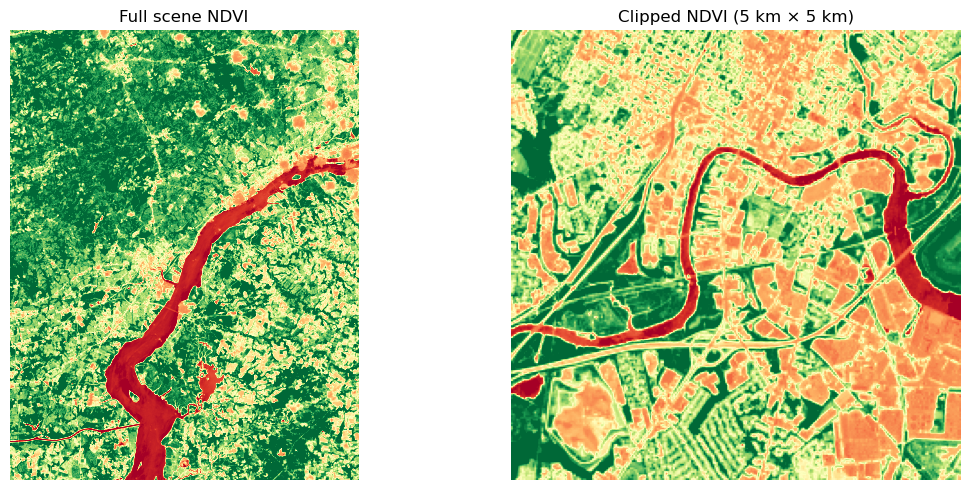

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

full_ndvi = ds["ndvi"].isel(time=0).compute().values
clip_ndvi = ds_clipped["ndvi"].isel(time=0).compute().values

axes[0].imshow(full_ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8, origin="upper")
axes[0].set_title("Full scene NDVI")
axes[0].axis("off")

axes[1].imshow(clip_ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8, origin="upper")
axes[1].set_title("Clipped NDVI (5 km × 5 km)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 4: Export GeoTIFF and Cloud-Optimized GeoTIFF

`rio.to_raster()` writes a GeoTIFF that any GIS tool can open. Passing `driver="COG"` writes a Cloud-Optimized GeoTIFF — a GeoTIFF with internal tiling and overviews arranged for efficient HTTP range reads.

In [7]:
import os
os.makedirs("../data", exist_ok=True)

ndvi_scene0 = ds_clipped["ndvi"].isel(time=0).compute()

# Standard GeoTIFF
ndvi_scene0.rio.to_raster("../data/ndvi_scene0.tif")
print("GeoTIFF written: ../data/ndvi_scene0.tif")
print(f"  File size: {os.path.getsize('../data/ndvi_scene0.tif') / 1e3:.1f} KB")

# Cloud-Optimized GeoTIFF via helper
write_cog(ndvi_scene0, "../data/ndvi_scene0_cog.tif")
print(f"  COG size:  {os.path.getsize('../data/ndvi_scene0_cog.tif') / 1e3:.1f} KB")

GeoTIFF written: ../data/ndvi_scene0.tif
  File size: 250.7 KB
COG written → ../data/ndvi_scene0_cog.tif
  COG size:  299.2 KB


## Inspect the COG with gdalinfo

`gdalinfo` reads GeoTIFF metadata from the file header — without reading pixel data. A COG will report `LAYOUT=COG` in the structural metadata.

In [8]:
import subprocess
result = subprocess.run(
    ["gdalinfo", "../data/ndvi_scene0_cog.tif"],
    capture_output=True,
    text=True,
)
if result.returncode == 0:
    # Print the first 40 lines — CRS, bounding box, band info
    lines = result.stdout.splitlines()
    for line in lines[:40]:
        print(line)
else:
    print("gdalinfo not available — install GDAL via conda-forge")
    print("Run: conda install -c conda-forge gdal")

Driver: GTiff/GeoTIFF
Files: ../data/ndvi_scene0_cog.tif
Size is 250, 250
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 18N",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]],
    CONVERSION["Transverse Mercator",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-75,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LE

## Validation

In [9]:
assert ds.rio.crs.to_epsg() == 32618, "CRS should be EPSG:32618"
assert ds_wgs84.rio.crs.to_epsg() == 4326, "Reprojected CRS should be EPSG:4326"
assert ds_clipped.rio.width < ds.rio.width, "Clip should reduce width"
assert ds_clipped.rio.height < ds.rio.height, "Clip should reduce height"
assert os.path.isfile("../data/ndvi_scene0.tif"), "GeoTIFF not written"
assert os.path.isfile("../data/ndvi_scene0_cog.tif"), "COG not written"
print("All assertions passed.")

All assertions passed.


---
## Learning Checkpoint — Q&A

**Q1:** What does `rio.write_crs()` actually do — where is the CRS stored in the xarray object?

> *It stores the CRS as a WKT string in the array's `.attrs` dict (under `grid_mapping`) and adds a `spatial_ref` coordinate variable with full WKT. This metadata is in-memory and is preserved when the Dataset is saved to Zarr.*

**Q2:** What is an Affine transform and what does it encode?

> *An Affine transform is a 3×3 matrix (stored as 6 numbers) that converts pixel indices `(col, row)` to spatial coordinates `(x, y)`. It encodes pixel width, pixel height (negative for north-up rasters), and the x/y coordinate of the top-left corner.*

**Q3:** When you reproject from EPSG:32618 to EPSG:4326, what happens to pixel values and resolution?

> *Pixel values are resampled (interpolated) onto a new grid — they are not simply relabelled. The grid shape changes because geographic degrees don't align with UTM metre cells. Resolution changes from metres to degrees.*

**Q4:** What makes a GeoTIFF "Cloud-Optimized" — how does its internal structure differ from a regular GeoTIFF?

> *A COG stores pixel data in internal tiles (e.g. 512×512) and prepends reduced-resolution overview images. This lets an HTTP client fetch only the tiles covering a spatial window via range requests — no need to download the whole file. A regular GeoTIFF stores data in strips without overviews.*